# GARCH Model and Volatility Forecasting

## From Historical Returns to Volatility Forecasts

The models in previous chapters (Black-Scholes, Heston, Merton) assume specific dynamics
for volatility. In practice, traders and risk managers also need to **measure and forecast
volatility from historical return data**. The **GARCH (Generalized Autoregressive Conditional
Heteroskedasticity)** family, introduced by Engle (1982) and Bollerslev (1986), is the
standard time-series tool for this.

## The Core Insight: Volatility Clusters

High-volatility periods tend to be followed by high volatility (e.g., the 2020 COVID crash),
and calm periods follow calm periods. GARCH captures this **volatility clustering** with a
simple recursive variance equation.

## Chapter Goals

1. Understand and simulate the GARCH(1,1) model
2. Estimate GARCH parameters from return data via MLE
3. Fit GARCH to real S&P 500 returns
4. Forecast the volatility term structure (multiple horizons)
5. Compare GARCH realized-vol forecasts to the implied volatility term structure from the Heston model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad
from math import erf, log, sqrt, exp
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## 1. The GARCH(1,1) Model

The return at time $t$ decomposes into a conditional mean and a heteroskedastic shock:

$$r_t = \mu + \epsilon_t, \qquad \epsilon_t = \sigma_t z_t, \qquad z_t \overset{iid}{\sim} \mathcal{N}(0,1)$$

The **conditional variance** $\sigma_t^2$ follows a GARCH(1,1) recursion:

$$\sigma_t^2 = \omega + \alpha\,\epsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2$$

| Parameter | Role | Constraint |
|-----------|------|------------|
| $\omega > 0$ | Variance floor | Ensures $\sigma_t^2 > 0$ |
| $\alpha \geq 0$ | Reaction to shocks (ARCH term) | Captures volatility jumps |
| $\beta \geq 0$ | Persistence of past variance | Captures slow mean-reversion |
| $\alpha + \beta < 1$ | Covariance stationarity | Required for finite unconditional variance |

The **unconditional (long-run) variance** is:

$$\bar{\sigma}^2 = \frac{\omega}{1 - \alpha - \beta}$$

For S&P 500, typical estimates are $\alpha \approx 0.07$, $\beta \approx 0.92$, so $\alpha+\beta \approx 0.99$ — shocks are highly persistent but eventually mean-revert.

In [2]:
np.random.seed(42)
n = 2000

# True GARCH(1,1) parameters
omega_true = 1e-5
alpha_true = 0.10
beta_true  = 0.85
mu_true    = 0.0

sigma2_lr_true = omega_true / (1 - alpha_true - beta_true)  # long-run variance

returns = np.zeros(n)
sigma2  = np.zeros(n)
sigma2[0] = sigma2_lr_true

for t in range(1, n):
    sigma2[t] = omega_true + alpha_true * returns[t-1]**2 + beta_true * sigma2[t-1]
    returns[t] = mu_true + np.sqrt(sigma2[t]) * np.random.randn()

sigma_ann = np.sqrt(sigma2 * 252)  # annualized conditional vol (decimal)

print(f'True parameters: omega={omega_true:.1e}, alpha={alpha_true}, beta={beta_true}, alpha+beta={alpha_true+beta_true}')
print(f'True long-run vol (ann.): {np.sqrt(sigma2_lr_true * 252)*100:.2f}%')
print(f'Simulated return std (ann.): {returns.std() * np.sqrt(252) * 100:.2f}%')

True parameters: omega=1.0e-05, alpha=0.1, beta=0.85, alpha+beta=0.95
True long-run vol (ann.): 22.45%
Simulated return std (ann.): 21.27%


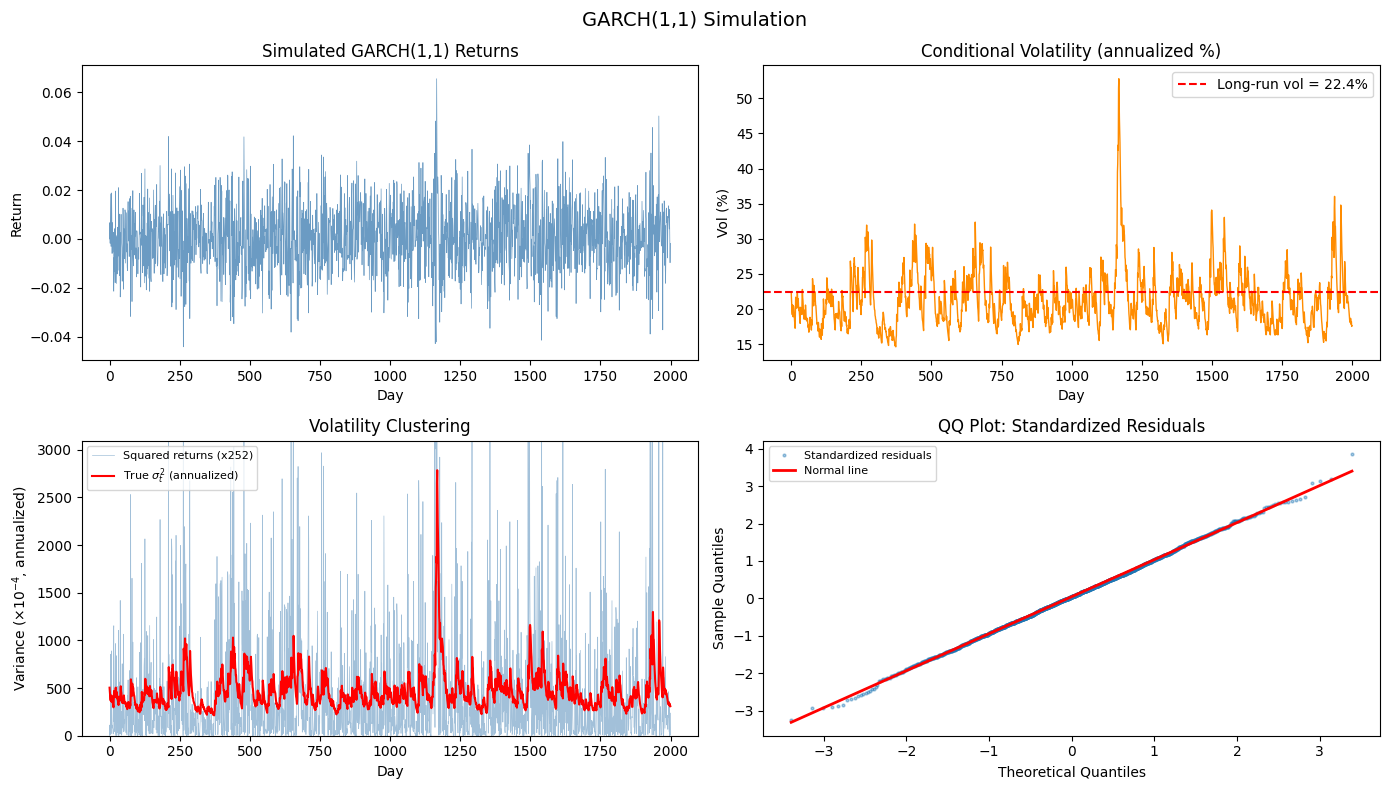

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Returns
axes[0, 0].plot(returns, linewidth=0.5, color='steelblue', alpha=0.8)
axes[0, 0].set_title('Simulated GARCH(1,1) Returns')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_ylabel('Return')

# Conditional volatility
lr_vol = np.sqrt(sigma2_lr_true * 252) * 100
axes[0, 1].plot(sigma_ann * 100, linewidth=1, color='darkorange')
axes[0, 1].axhline(lr_vol, color='red', linestyle='--', linewidth=1.5,
                    label=f'Long-run vol = {lr_vol:.1f}%')
axes[0, 1].set_title('Conditional Volatility (annualized %)')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Vol (%)')
axes[0, 1].legend()

# Volatility clustering
sq_ann   = returns**2 * 252 * 1e4
sig2_ann = sigma2  * 252 * 1e4
axes[1, 0].plot(sq_ann,   linewidth=0.5, color='steelblue', alpha=0.5, label='Squared returns (x252)')
axes[1, 0].plot(sig2_ann, linewidth=1.5, color='red',       label=r'True $\sigma_t^2$ (annualized)')
axes[1, 0].set_title('Volatility Clustering')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel(r'Variance ($\times 10^{-4}$, annualized)')
axes[1, 0].set_ylim(0, np.percentile(sq_ann, 99))
axes[1, 0].legend(fontsize=8)

# QQ plot of standardized residuals
z_t = returns / np.sqrt(sigma2)
(osm, osr), (slope, intercept, _) = stats.probplot(z_t, dist='norm')
axes[1, 1].plot(osm, osr, 'o', markersize=2, alpha=0.4, label='Standardized residuals')
axes[1, 1].plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=2, label='Normal line')
axes[1, 1].set_title('QQ Plot: Standardized Residuals')
axes[1, 1].set_xlabel('Theoretical Quantiles')
axes[1, 1].set_ylabel('Sample Quantiles')
axes[1, 1].legend(fontsize=8)

plt.suptitle('GARCH(1,1) Simulation', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Parameter Estimation via Maximum Likelihood

Given return data $\{r_t\}_{t=1}^T$, we estimate $\theta = (\mu, \omega, \alpha, \beta)$ by maximizing the Gaussian log-likelihood:

$$\ell(\theta) = -\frac{1}{2}\sum_{t=1}^T \left[\log(2\pi) + \log \sigma_t^2(\theta) + \frac{(r_t - \mu)^2}{\sigma_t^2(\theta)}\right]$$

The variance sequence $\sigma_t^2(\theta)$ is computed recursively from the data for each candidate $\theta$. We use the `arch` library, which implements efficient numerical MLE with analytical gradients.

In [4]:
from arch import arch_model

# arch library works with percentage returns; scale by 100
am_sim  = arch_model(returns * 100, mean='Constant', vol='GARCH', p=1, q=1, dist='Normal')
res_sim = am_sim.fit(disp='off')

omega_hat = res_sim.params['omega'] / 1e4   # back to decimal units
alpha_hat = res_sim.params['alpha[1]']
beta_hat  = res_sim.params['beta[1]']
sigma2_lr_hat = omega_hat / (1 - alpha_hat - beta_hat)

print('=== GARCH(1,1) Parameter Recovery ===')
print(f"{'Parameter':>12s}  {'True':>10s}  {'Estimated':>10s}")
print(f"{'omega':>12s}  {omega_true:>10.2e}  {omega_hat:>10.2e}")
print(f"{'alpha':>12s}  {alpha_true:>10.4f}  {alpha_hat:>10.4f}")
print(f"{'beta':>12s}  {beta_true:>10.4f}  {beta_hat:>10.4f}")
print(f"{'alpha+beta':>12s}  {alpha_true+beta_true:>10.4f}  {alpha_hat+beta_hat:>10.4f}")
true_lrvol = np.sqrt(sigma2_lr_true * 252) * 100
est_lrvol  = np.sqrt(sigma2_lr_hat  * 252) * 100
print(f'\nLong-run vol (ann.):  True = {true_lrvol:.2f}%   Est. = {est_lrvol:.2f}%')

=== GARCH(1,1) Parameter Recovery ===
   Parameter        True   Estimated
       omega    1.00e-05    1.72e-05
       alpha      0.1000      0.1008
        beta      0.8500      0.8034
  alpha+beta      0.9500      0.9042

Long-run vol (ann.):  True = 22.45%   Est. = 21.25%


## 3. GARCH on Real Market Data: S&P 500

We apply GARCH(1,1) to five years of S&P 500 daily log returns (2019–2024). The COVID crash (Feb–Apr 2020), 2022 rate-hike drawdown, and other turbulent periods should produce visible spikes in estimated conditional volatility — the signature of volatility clustering in real data.

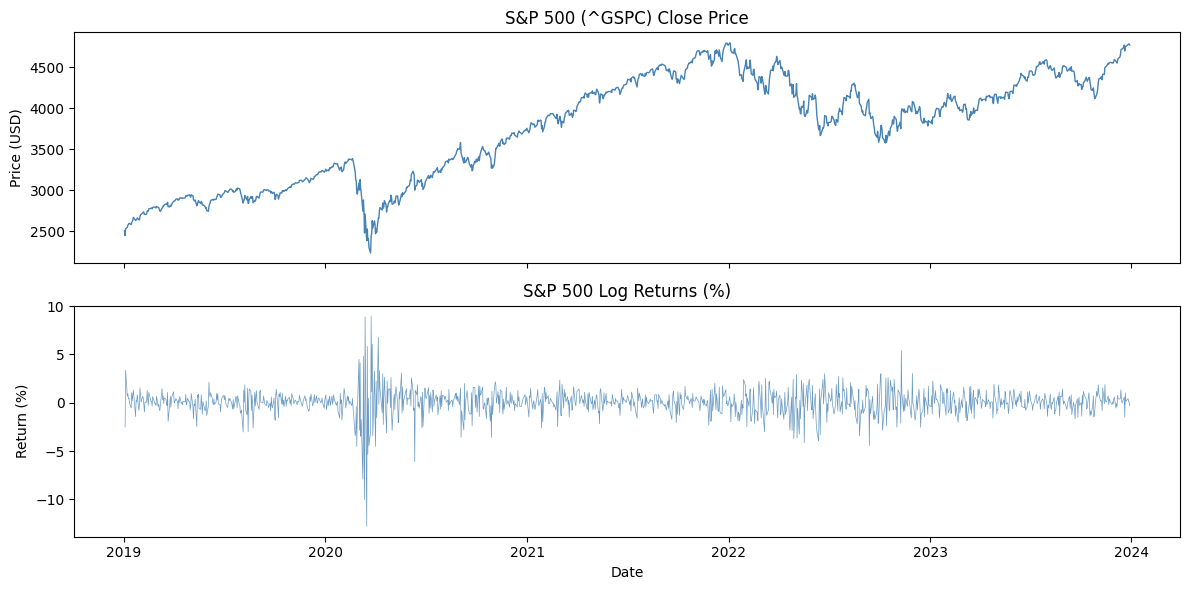

Period       : 2019-01-02 to 2023-12-29
Trading days : 1257
Mean daily return : 0.0511%
Daily return std  : 1.3490%  (ann. 21.41%)


In [5]:
import yfinance as yf

spy = yf.download('^GSPC', start='2019-01-01', end='2024-01-01',
                  progress=False, auto_adjust=True)
prices      = spy['Close'].squeeze().dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(prices.index, prices.values, linewidth=1, color='steelblue')
axes[0].set_title('S&P 500 (^GSPC) Close Price')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(log_returns.index, log_returns.values * 100, linewidth=0.5,
             color='steelblue', alpha=0.8)
axes[1].set_title('S&P 500 Log Returns (%)')
axes[1].set_ylabel('Return (%)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

print(f'Period       : {prices.index[0].date()} to {prices.index[-1].date()}')
print(f'Trading days : {len(log_returns)}')
print(f'Mean daily return : {log_returns.mean()*100:.4f}%')
print(f'Daily return std  : {log_returns.std()*100:.4f}%  '
      f'(ann. {log_returns.std()*np.sqrt(252)*100:.2f}%)')

=== S&P 500 GARCH(1,1) Estimates ===
omega      = 0.045658  (%/day)^2
alpha      = 0.190309
beta       = 0.785836
alpha+beta = 0.976145
Long-run daily vol : 1.3835%
Long-run annual vol: 21.96%


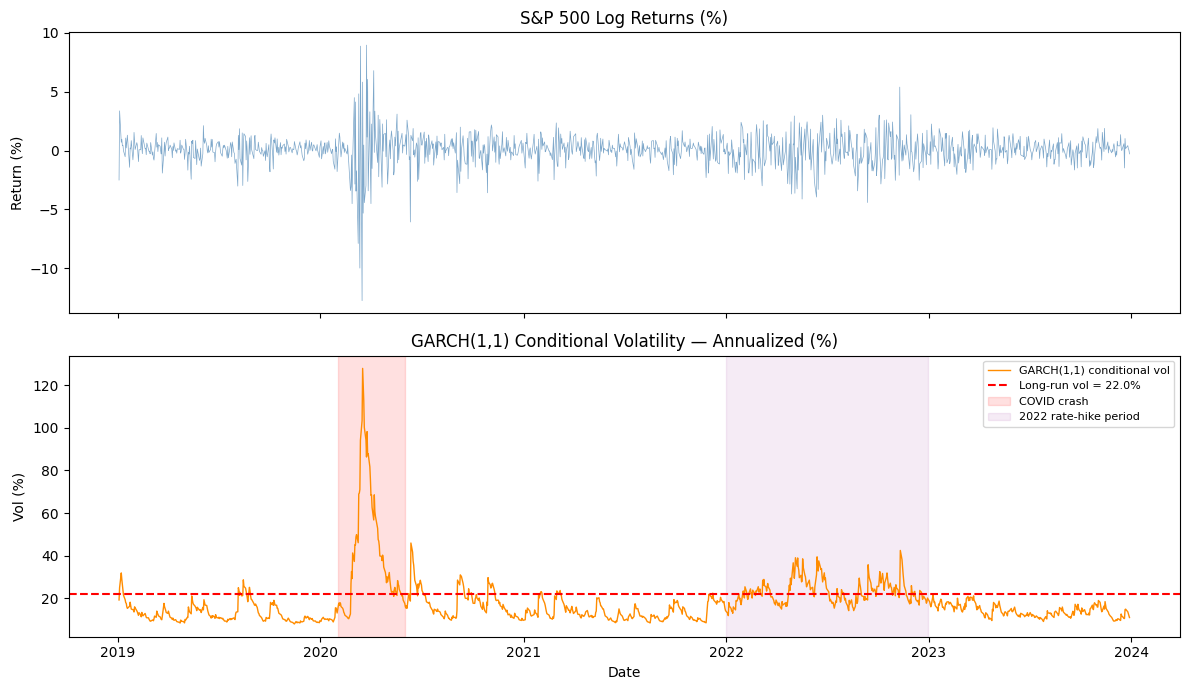

In [6]:
import pandas as pd

am_spy  = arch_model(log_returns * 100, mean='Constant', vol='GARCH', p=1, q=1, dist='Normal')
res_spy = am_spy.fit(disp='off')

omega_spy = res_spy.params['omega']
alpha_spy = res_spy.params['alpha[1]']
beta_spy  = res_spy.params['beta[1]']
pers_spy  = alpha_spy + beta_spy
sigma2_lr_spy = omega_spy / (1 - pers_spy)   # long-run variance in (%/day)^2

print('=== S&P 500 GARCH(1,1) Estimates ===')
print(f'omega      = {omega_spy:.6f}  (%/day)^2')
print(f'alpha      = {alpha_spy:.6f}')
print(f'beta       = {beta_spy:.6f}')
print(f'alpha+beta = {pers_spy:.6f}')
print(f'Long-run daily vol : {np.sqrt(sigma2_lr_spy):.4f}%')
print(f'Long-run annual vol: {np.sqrt(sigma2_lr_spy * 252):.2f}%')

cond_vol_ann = res_spy.conditional_volatility * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(log_returns.index, log_returns.values * 100, linewidth=0.5,
             color='steelblue', alpha=0.7)
axes[0].set_title('S&P 500 Log Returns (%)')
axes[0].set_ylabel('Return (%)')

lr_ann = np.sqrt(sigma2_lr_spy * 252)
axes[1].plot(cond_vol_ann.index, cond_vol_ann.values, linewidth=1,
             color='darkorange', label='GARCH(1,1) conditional vol')
axes[1].axhline(lr_ann, color='red', linestyle='--', linewidth=1.5,
                label=f'Long-run vol = {lr_ann:.1f}%')
axes[1].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'),
                alpha=0.12, color='red', label='COVID crash')
axes[1].axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
                alpha=0.08, color='purple', label='2022 rate-hike period')
axes[1].set_title('GARCH(1,1) Conditional Volatility — Annualized (%)')
axes[1].set_ylabel('Vol (%)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Volatility Term Structure from GARCH

A key output of GARCH is the **volatility term structure**: the expected average annualized
volatility over different horizons, given today's conditional variance $\sigma_{t+1}^2$.

The GARCH(1,1) $h$-step-ahead conditional variance satisfies:

$$E_t[\sigma_{t+h}^2] = \bar{\sigma}^2 + (\alpha+\beta)^{h-1}\bigl(\sigma_{t+1}^2 - \bar{\sigma}^2\bigr)$$

The **average variance** over horizon $H$ (the relevant quantity for option pricing) is:

$$\bar{\sigma}^2(H) = \frac{1}{H}\sum_{h=1}^{H}E_t[\sigma_{t+h}^2]
  = \bar{\sigma}^2 + \frac{1 - (\alpha+\beta)^H}{H\,(1-\alpha-\beta)}\bigl(\sigma_{t+1}^2 - \bar{\sigma}^2\bigr)$$

**Intuition:**
- Current vol **above** long-run $\Rightarrow$ term structure slopes **downward** (vol mean-reverts down)
- Current vol **below** long-run $\Rightarrow$ term structure slopes **upward** (vol mean-reverts up)
- Persistence $\alpha+\beta \to 1$ (IGARCH) $\Rightarrow$ shocks permanent, flat term structure

GARCH(1,1) Volatility Term Structure  (as of last observation)
Current daily vol  : 0.6971%  (ann. 11.07%)
Long-run annual vol: 21.96%

 Horizon   Days   GARCH Vol (%)
      1w      5           11.80%
      1m     21           14.02%
      3m     63           17.18%
      6m    126           19.19%
      1y    252           20.56%


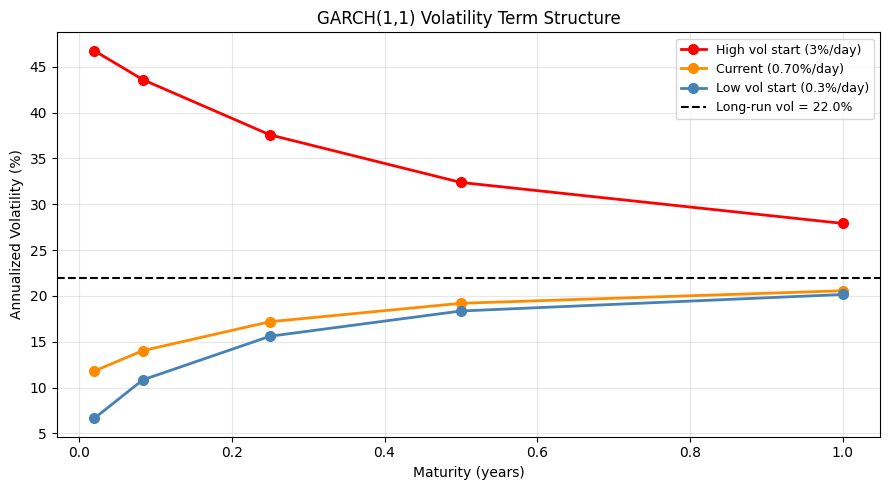

In [7]:
# Forecast horizons
horizons_days  = np.array([5, 21, 63, 126, 252])
horizon_labels = ['1w', '1m', '3m', '6m', '1y']
horizons_years = horizons_days / 252.0

# Latest conditional variance in (%/day)^2
sigma2_last_spy = res_spy.conditional_volatility.iloc[-1]**2

def garch_avg_vol(H, sigma2_0, omega, alpha, beta):
    # Annualized vol from average GARCH variance over H days (units: %/day)
    pers = alpha + beta
    sigma2_lr = omega / (1 - pers)
    if H == 0:
        return np.sqrt(sigma2_0 * 252)
    factor  = (1 - pers**H) / (H * (1 - pers))
    avg_var = sigma2_lr + factor * (sigma2_0 - sigma2_lr)
    return np.sqrt(avg_var * 252)

garch_vols = np.array([garch_avg_vol(h, sigma2_last_spy, omega_spy, alpha_spy, beta_spy)
                        for h in horizons_days])

print('GARCH(1,1) Volatility Term Structure  (as of last observation)')
print(f'Current daily vol  : {np.sqrt(sigma2_last_spy):.4f}%  '
      f'(ann. {np.sqrt(sigma2_last_spy*252):.2f}%)')
print(f'Long-run annual vol: {np.sqrt(sigma2_lr_spy*252):.2f}%')
print()
print(f"{'Horizon':>8s}  {'Days':>5s}  {'GARCH Vol (%)':>14s}")
for lbl, h, v in zip(horizon_labels, horizons_days, garch_vols):
    print(f'{lbl:>8s}  {h:>5d}  {v:>14.2f}%')

# Show term structure under three starting scenarios
sigma2_high = (3.0)**2
sigma2_low  = (0.3)**2

fig, ax = plt.subplots(figsize=(9, 5))
for sigma2_start, lbl, color in [
    (sigma2_high,     'High vol start (3%/day)',                     'red'),
    (sigma2_last_spy, f'Current ({np.sqrt(sigma2_last_spy):.2f}%/day)', 'darkorange'),
    (sigma2_low,      'Low vol start (0.3%/day)',                    'steelblue'),
]:
    vols = [garch_avg_vol(h, sigma2_start, omega_spy, alpha_spy, beta_spy)
            for h in horizons_days]
    ax.plot(horizons_years, vols, 'o-', linewidth=2, markersize=7,
            label=lbl, color=color)

ax.axhline(np.sqrt(sigma2_lr_spy * 252), color='black', linestyle='--', linewidth=1.5,
           label=f'Long-run vol = {np.sqrt(sigma2_lr_spy*252):.1f}%')
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Annualized Volatility (%)')
ax.set_title('GARCH(1,1) Volatility Term Structure')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. GARCH Forecasts vs. Implied Volatility Term Structure

GARCH forecasts **realized volatility** under the physical measure $\mathbb{P}$ — the expected
future fluctuation of returns. Implied volatility from options is priced under the risk-neutral
measure $\mathbb{Q}$ and includes a **volatility risk premium**:

$$\underbrace{\sigma_{\text{imp}}(T)}_{\text{implied (risk-neutral)}}
  \approx
  \underbrace{\sigma_{\text{GARCH}}(T)}_{\text{realized forecast (physical)}}
  + \underbrace{\Lambda(T)}_{\text{vol risk premium}}$$

The risk premium $\Lambda > 0$ on average because investors pay extra for options as insurance
against volatility spikes. We compare the GARCH S&P 500 term structure against the ATM
implied-vol term structure from the Heston model calibrated in Chapter 10.

> **Note:** The Heston parameters here are stylized, not calibrated to the same date as the
> GARCH fit. In live practice you would calibrate Heston to observed option prices and compare
> to the GARCH forecast from the same snapshot.

In [8]:
# Black-Scholes helpers
def bs_cdf(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

def bs_call(S, K, r, T, sigma):
    d1 = (log(S/K) + (r + sigma**2/2)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    return S * bs_cdf(d1) - K * exp(-r*T) * bs_cdf(d2)

def implied_vol_newton(market_price, S, K, r, T, tol=1e-8, max_iter=100):
    sig = 0.3
    for _ in range(max_iter):
        price = bs_call(S, K, r, T, sig)
        d1    = (log(S/K) + (r + sig**2/2)*T) / (sig*sqrt(T))
        vega  = S * np.exp(-d1**2/2) / sqrt(2*np.pi) * sqrt(T)
        diff  = price - market_price
        if abs(diff) < tol:
            return sig
        if vega < 1e-12:
            return np.nan
        sig -= diff / vega
        if sig < 1e-6:
            sig = 1e-6
    return np.nan

# Heston semi-analytical pricer
def heston_char_func(u, S0, r, T, v0, kappa, theta, xi, rho, j):
    x     = np.log(S0)
    b     = kappa - rho * xi if j == 1 else kappa
    u_adj = 0.5             if j == 1 else -0.5
    d = np.sqrt((rho * xi * 1j * u - b)**2 - xi**2 * (2 * u_adj * 1j * u - u**2))
    g = (b - rho * xi * 1j * u + d) / (b - rho * xi * 1j * u - d)
    C = r * 1j * u * T + (kappa * theta / xi**2) * (
        (b - rho * xi * 1j * u + d) * T
        - 2 * np.log((1 - g * np.exp(d * T)) / (1 - g)))
    D = ((b - rho * xi * 1j * u + d) / xi**2) * (
        (1 - np.exp(d * T)) / (1 - g * np.exp(d * T)))
    return np.exp(C + D * v0 + 1j * u * x)

def heston_call(S0, K, r, T, v0, kappa, theta, xi, rho):
    def integrand(u, j):
        phi = heston_char_func(u, S0, r, T, v0, kappa, theta, xi, rho, j)
        return np.real(np.exp(-1j * u * np.log(K)) * phi / (1j * u))
    I1, _ = quad(lambda u: integrand(u, 1), 0, 200, limit=200)
    I2, _ = quad(lambda u: integrand(u, 2), 0, 200, limit=200)
    return S0 * (0.5 + I1/np.pi) - K * np.exp(-r*T) * (0.5 + I2/np.pi)

# Heston parameters from Chapter 10
S0_h, r_h = 100.0, 0.05
v0_h, kappa_h, theta_h, xi_h, rho_h = 0.04, 2.0, 0.04, 0.4, -0.7

# ATM implied vol at each forecast horizon
heston_ivs = []
for T_i in horizons_years:
    K_atm = S0_h * exp(r_h * T_i)   # ATM = forward price
    price  = heston_call(S0_h, K_atm, r_h, T_i, v0_h, kappa_h, theta_h, xi_h, rho_h)
    iv     = implied_vol_newton(price, S0_h, K_atm, r_h, T_i)
    heston_ivs.append(float('nan') if (iv is None or np.isnan(iv)) else iv * 100)

heston_ivs = np.array(heston_ivs)

print('Heston ATM Implied Volatility Term Structure')
print(f"{'Horizon':>8s}  {'IV (%)':>10s}")
for lbl, iv in zip(horizon_labels, heston_ivs):
    print(f'{lbl:>8s}  {iv:>10.2f}%')

Heston ATM Implied Volatility Term Structure
 Horizon      IV (%)
      1w       19.93%
      1m       19.72%
      3m       19.29%
      6m       18.89%
      1y       18.61%


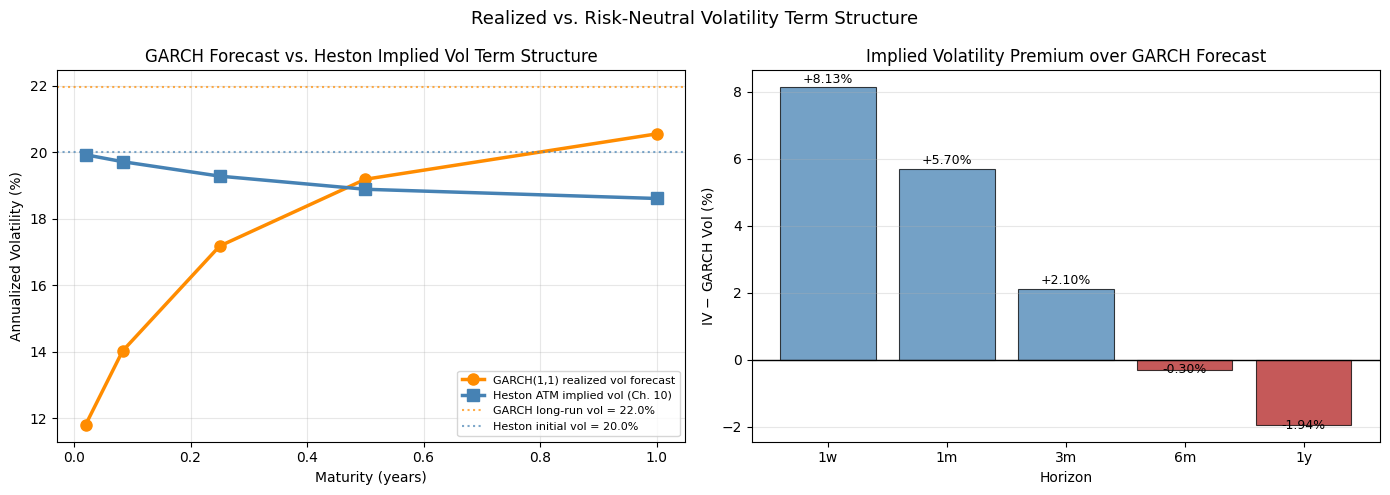

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Overlay
ax = axes[0]
ax.plot(horizons_years, garch_vols, 'o-', linewidth=2.5, markersize=8,
        color='darkorange', label='GARCH(1,1) realized vol forecast')
ax.plot(horizons_years, heston_ivs, 's-', linewidth=2.5, markersize=8,
        color='steelblue', label='Heston ATM implied vol (Ch. 10)')
ax.axhline(np.sqrt(sigma2_lr_spy * 252), color='darkorange', linestyle=':',
           linewidth=1.5, alpha=0.7,
           label=f'GARCH long-run vol = {np.sqrt(sigma2_lr_spy*252):.1f}%')
ax.axhline(np.sqrt(v0_h) * 100, color='steelblue', linestyle=':',
           linewidth=1.5, alpha=0.7,
           label=f'Heston initial vol = {np.sqrt(v0_h)*100:.1f}%')
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Annualized Volatility (%)')
ax.set_title('GARCH Forecast vs. Heston Implied Vol Term Structure')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (b) Volatility risk premium
ax2 = axes[1]
risk_premium = heston_ivs - garch_vols
colors = ['steelblue' if x >= 0 else 'firebrick' for x in risk_premium]
bars = ax2.bar(horizon_labels, risk_premium, color=colors,
               alpha=0.75, edgecolor='black', linewidth=0.8)
ax2.axhline(0, color='black', linewidth=1)
for bar, val in zip(bars, risk_premium):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + (0.05 if val >= 0 else -0.2),
             f'{val:+.2f}%', ha='center', va='bottom', fontsize=9)
ax2.set_xlabel('Horizon')
ax2.set_ylabel(r'IV $-$ GARCH Vol (%)')
ax2.set_title('Implied Volatility Premium over GARCH Forecast')
ax2.grid(alpha=0.3, axis='y')

plt.suptitle('Realized vs. Risk-Neutral Volatility Term Structure', fontsize=13)
plt.tight_layout()
plt.show()

## Summary

The GARCH(1,1) model captures **volatility clustering** in financial returns with a parsimonious recursion:

$$\sigma_t^2 = \omega + \alpha\,\epsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2$$

| Concept | Key result |
|---------|------------|
| **Volatility clustering** | Large $\beta$ ($\approx 0.9$) makes shocks persistent |
| **Mean reversion** | Variance reverts to $\bar{\sigma}^2 = \omega/(1-\alpha-\beta)$ |
| **Persistence** | $\alpha+\beta \approx 0.95$–$0.99$ for equity indices |
| **Term structure** | Slopes down (up) when current vol is above (below) long-run |

### GARCH vs. Implied Volatility

| Feature | GARCH forecast | Implied Vol (Heston) |
|---------|---------------|----------------------|
| Probability measure | Physical $\mathbb{P}$ | Risk-neutral $\mathbb{Q}$ |
| Data source | Historical returns | Option prices |
| Includes vol risk premium | No | Yes |
| Typical level | Lower | Higher |

The gap between implied and GARCH volatility — the **volatility risk premium** — is positive on average. Investors willingly overpay for options as insurance against volatility spikes, making implied vol persistently higher than the GARCH realized-vol forecast.